###**Import required libraries and set random seeds for reproducibility**

In [1]:
import keras
from keras import ops
from keras import layers
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### **Define custom Keras layers: TokenAndPositionEmbedding and TransformerBlock for the encoder**

In [2]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = ops.shape(x)[-1]
        positions = ops.arange(start=0, stop=maxlen, step=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):  #Training parameter
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

### **Load and preprocess Reuters dataset with specified parameters (vocab_size=10000, maxlen=200)**

In [3]:
vocab_size = 10000
maxlen = 200
embed_dim = 32
num_heads = 4
ff_dim1 = 32  #For first and last blocks
ff_dim2 = 64  #For intermediate blocks

print("Loading Reuters dataset...")
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=vocab_size)

#Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

num_classes = np.max(y_train) + 1
print(f"\nDataset Statistics:")
print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Number of classes: {num_classes}")
print(f"Sample label: {y_train[0]}")

Loading Reuters dataset...
2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

Dataset Statistics:
Training samples: 8982
Test samples: 2246
Number of classes: 46
Sample label: 3


### **Build transformer model function with variable layers and different FFN dimensions for intermediate blocks**

In [4]:
def build_transformer_model(num_transformer_layers):
    print(f"\nBuilding model with {num_transformer_layers} transformer layers:")

    inputs = layers.Input(shape=(maxlen,))
    embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
    x = embedding_layer(inputs)

    #FIRST BLOCK (ff_dim1=32)
    print(f"  First block: ff_dim={ff_dim1}")
    x = TransformerBlock(embed_dim, num_heads, ff_dim1)(x)

    #INTERMEDIATE BLOCKS (ff_dim2=64)
    num_intermediate = num_transformer_layers - 2
    for i in range(num_intermediate):
        print(f"  Intermediate block {i+1}/{num_intermediate}: ff_dim={ff_dim2}")
        x = TransformerBlock(embed_dim, num_heads, ff_dim2)(x)

    #LAST BLOCK (ff_dim1=32) - only if num_transformer_layers > 1
    if num_transformer_layers > 1:
        print(f"  Last block: ff_dim={ff_dim1}")
        x = TransformerBlock(embed_dim, num_heads, ff_dim1)(x)

    #Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    #Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### **Training and evaluation function to train models for 10 epochs with validation split**

In [5]:
def train_and_evaluate_model(model, x_train, y_train, x_test, y_test, num_layers, epochs=10):
    print(f"\nTraining model with {num_layers} transformer layers for {epochs} epochs...")

    # Training the  model
    history = model.fit(
        x_train, y_train,
        batch_size=32,
        epochs=epochs,
        validation_split=0.2,
        verbose=1
    )

    # Evaluating on test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

    # Making predictions
    y_pred_probs = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return y_pred, history, test_acc

### **Run experiments for 3, 5, and 7 transformer layers, storing metrics and confusion matrices**

In [6]:
#Experimenting with different number of transformer layers
layer_settings = [3, 5, 7]
f1_scores = {}
conf_matrices = {}
histories = {}
accuracies = {}

print("STARTING EXPERIMENTS...")

for L in layer_settings:
    print(f"\n{'='*60}")
    print(f"TRAINING MODEL WITH {L} TRANSFORMER LAYERS")
    print(f"{'='*60}")

    #Build and train model
    model = build_transformer_model(num_transformer_layers=L)
    y_pred, history, test_acc = train_and_evaluate_model(
        model, x_train, y_train, x_test, y_test, num_layers=L, epochs=10
    )

    #Calculate metrics
    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_scores[L] = f1
    accuracies[L] = test_acc
    histories[L] = history

    #Store confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[L] = cm

    print(f"\nWeighted F1 Score: {f1:.4f}")
    print(f"Macro F1 Score: {f1_score(y_test, y_pred, average='macro'):.4f}")

STARTING EXPERIMENTS...

TRAINING MODEL WITH 3 TRANSFORMER LAYERS

Building model with 3 transformer layers:
  First block: ff_dim=32
  Intermediate block 1/1: ff_dim=64
  Last block: ff_dim=32

Training model with 3 transformer layers for 10 epochs...
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.3904 - loss: 2.4380 - val_accuracy: 0.6594 - val_loss: 1.3916
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6810 - loss: 1.3038 - val_accuracy: 0.7351 - val_loss: 1.0863
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7741 - loss: 0.9287 - val_accuracy: 0.7479 - val_loss: 1.0513
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8337 - loss: 0.7099 - val_accuracy: 0.7418 - val_loss: 1.1501
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8597 - loss: 0.5680 - val_accuracy: 0.7451 - val_loss: 1.2081
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8828 - loss: 0.4752 - val_accuracy

### **Generate and display confusion matrices for each transformer layer configuration**

GENERATING CONFUSION MATRICES



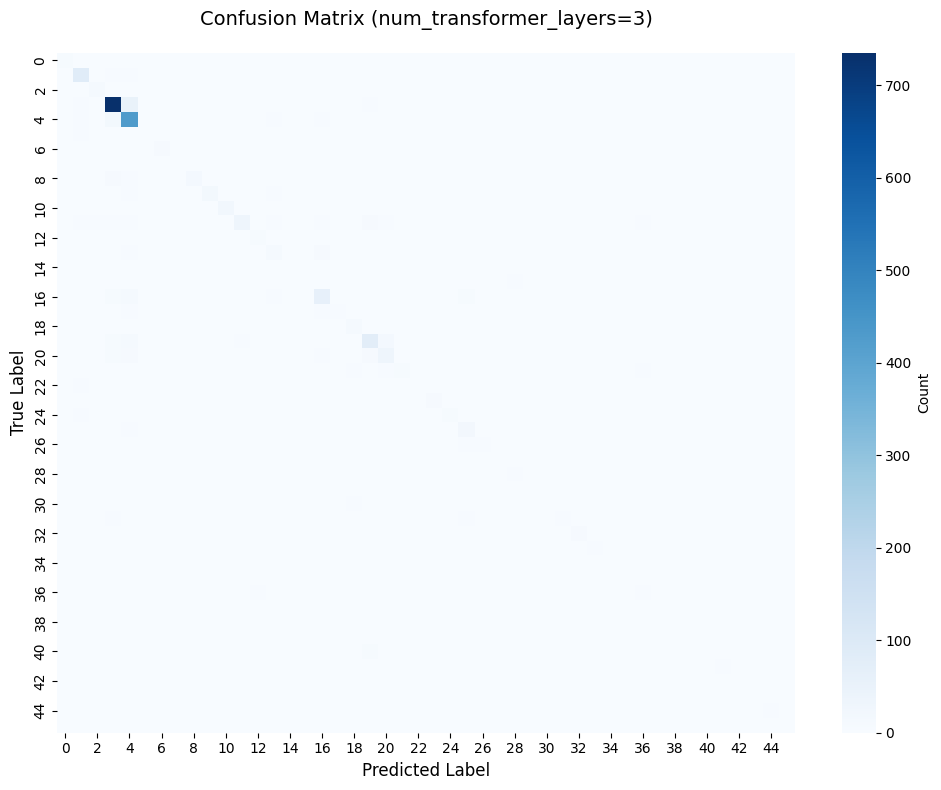


Classification Report for 3 layers:
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.4000    0.3333    0.3636        12
           1     0.6814    0.7333    0.7064       105
           2     0.2609    0.3000    0.2791        20
           3     0.9359    0.8807    0.9075       813
           4     0.8198    0.7679    0.7930       474
           5     0.0000    0.0000    0.0000         5
           6     0.7500    0.8571    0.8000        14
           7     0.0000    0.0000    0.0000         3
           8     0.6250    0.3947    0.4839        38
           9     0.7000    0.8400    0.7636        25
          10     0.7097    0.7333    0.7213        30
          11     0.4854    0.6024    0.5376        83
          12     0.1111    0.0769    0.0909        13
          13     0.4400    0.2973    0.3548        37
          14     0.0000    0.0000    0.0000         2
          15     0.0000    0.0000    0.0000    

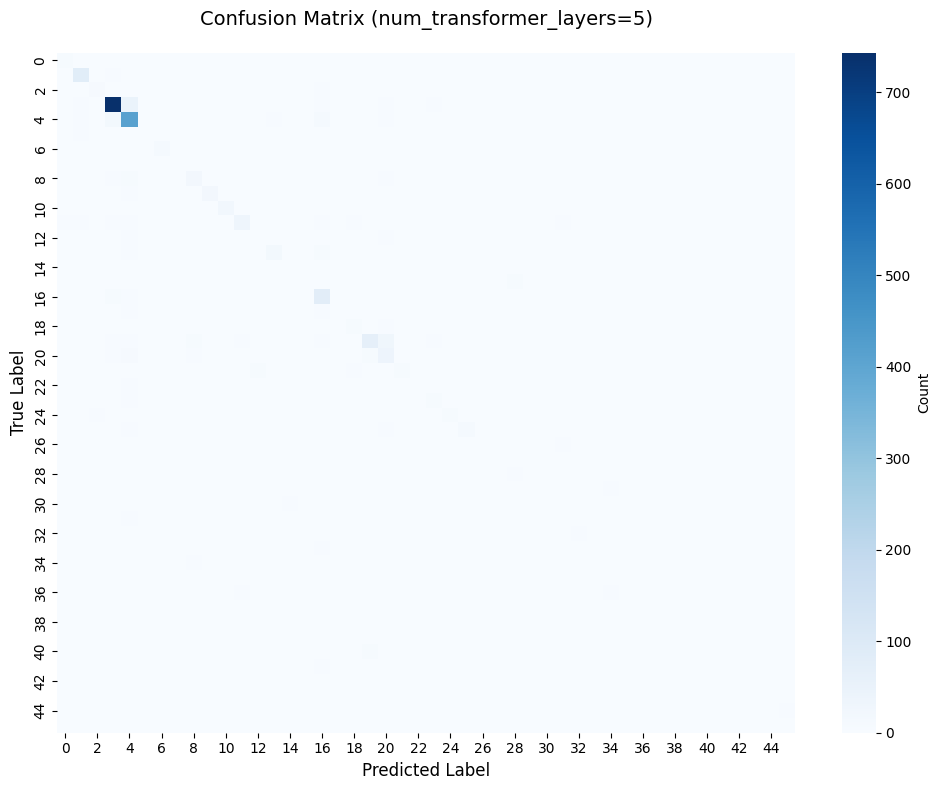


Classification Report for 5 layers:
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.4000    0.3333    0.3636        12
           1     0.6814    0.7333    0.7064       105
           2     0.2609    0.3000    0.2791        20
           3     0.9359    0.8807    0.9075       813
           4     0.8198    0.7679    0.7930       474
           5     0.0000    0.0000    0.0000         5
           6     0.7500    0.8571    0.8000        14
           7     0.0000    0.0000    0.0000         3
           8     0.6250    0.3947    0.4839        38
           9     0.7000    0.8400    0.7636        25
          10     0.7097    0.7333    0.7213        30
          11     0.4854    0.6024    0.5376        83
          12     0.1111    0.0769    0.0909        13
          13     0.4400    0.2973    0.3548        37
          14     0.0000    0.0000    0.0000         2
          15     0.0000    0.0000    0.0000    

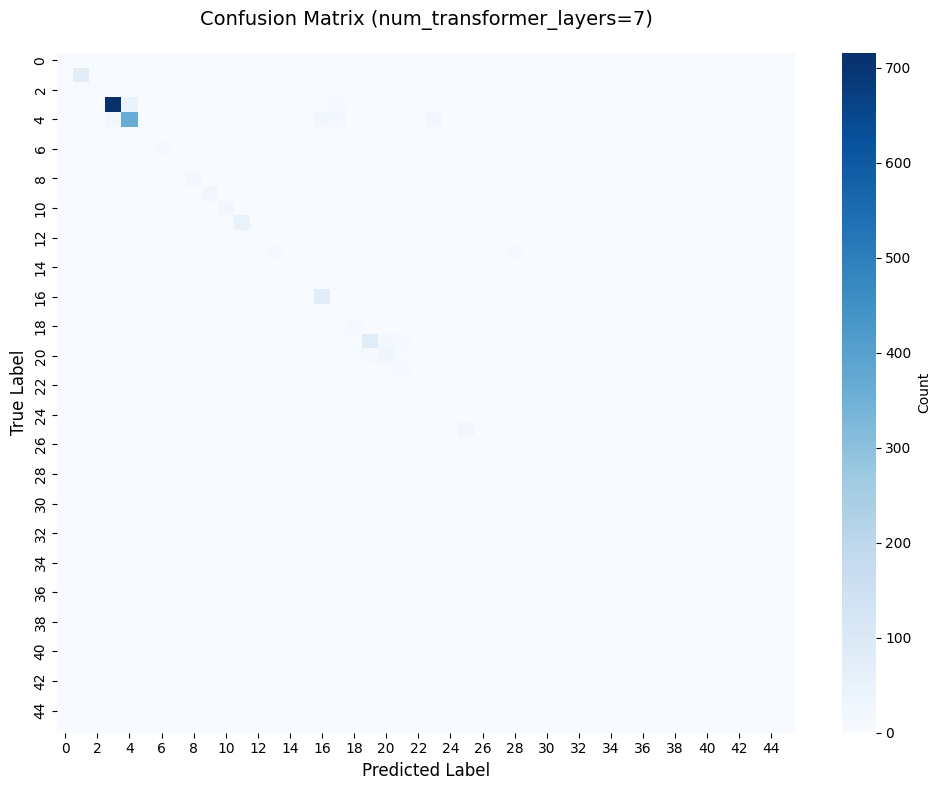


Classification Report for 7 layers:
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.4000    0.3333    0.3636        12
           1     0.6814    0.7333    0.7064       105
           2     0.2609    0.3000    0.2791        20
           3     0.9359    0.8807    0.9075       813
           4     0.8198    0.7679    0.7930       474
           5     0.0000    0.0000    0.0000         5
           6     0.7500    0.8571    0.8000        14
           7     0.0000    0.0000    0.0000         3
           8     0.6250    0.3947    0.4839        38
           9     0.7000    0.8400    0.7636        25
          10     0.7097    0.7333    0.7213        30
          11     0.4854    0.6024    0.5376        83
          12     0.1111    0.0769    0.0909        13
          13     0.4400    0.2973    0.3548        37
          14     0.0000    0.0000    0.0000         2
          15     0.0000    0.0000    0.0000    

In [7]:
print("GENERATING CONFUSION MATRICES\n")

for L in layer_settings:
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrices[L], annot=False, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
    plt.title(f"Confusion Matrix (num_transformer_layers={L})", fontsize=14, pad=20)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Optional: Print classification report
    print(f"\nClassification Report for {L} layers:")
    print("-"*50)
    print(classification_report(y_test, y_pred, digits=4))

### **Compare performance metrics and identify the best performing transformer configuration**

In [8]:
print("PERFORMANCE COMPARISON\n")

#Displaying results in table format
print("\nModel Performance Summary:")
print("-" * 60)
print(f"{'Layers':<10} {'Test Accuracy':<15} {'F1-Score (Weighted)':<20}")
print("-" * 60)

best_f1 = 0
best_layers = None

for L in layer_settings:
    f1 = f1_scores[L]
    acc = accuracies[L]
    print(f"{L:<10} {acc:.4f}           {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_layers = L

print("-" * 60)
print(f"\nBEST PERFORMING MODEL: num_transformer_layers = {best_layers}")
print(f"Best F1-Score: {best_f1:.4f}")
print(f"Best Test Accuracy: {accuracies[best_layers]:.4f}")

PERFORMANCE COMPARISON


Model Performance Summary:
------------------------------------------------------------
Layers     Test Accuracy   F1-Score (Weighted) 
------------------------------------------------------------
3          0.7502           0.7409
5          0.7315           0.7223
7          0.6883           0.6905
------------------------------------------------------------

BEST PERFORMING MODEL: num_transformer_layers = 3
Best F1-Score: 0.7409
Best Test Accuracy: 0.7502


### **Plot training history (accuracy curves) for all transformer layer configurations**

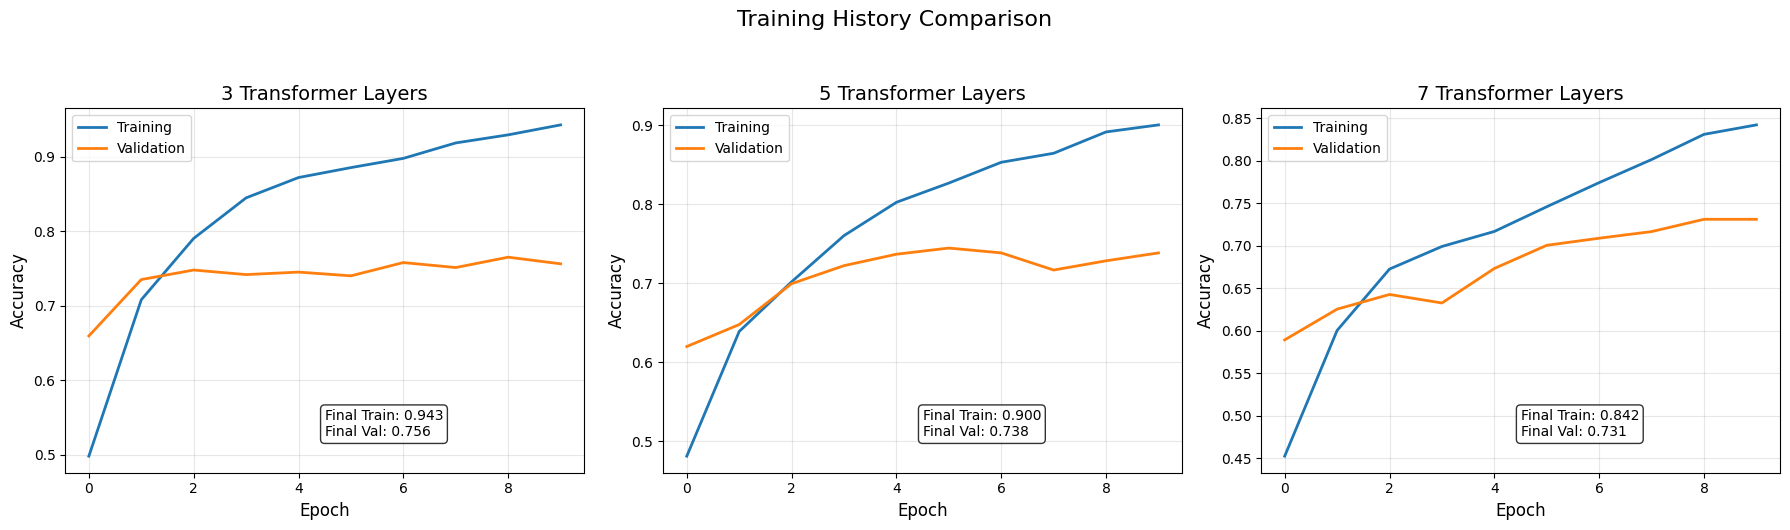

In [9]:
#Plotting training histories for all configurations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History Comparison', fontsize=16, y=1.05)

for idx, L in enumerate(layer_settings):
    history = histories[L]

    ax = axes[idx]
    ax.plot(history.history['accuracy'], label='Training', linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax.set_title(f'{L} Transformer Layers', fontsize=14)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Annotate final accuracy
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    ax.text(0.5, 0.1, f'Final Train: {final_train_acc:.3f}\nFinal Val: {final_val_acc:.3f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### **Create F1-score comparison bar chart between 6 assignment models and 3 transformer models**

Assignment Models F1-Scores:
  SimpleRNN: 0.2685
  LSTM: 0.5552
  GRU: 0.5540
  BiSimpleRNN: 0.6195
  BiLSTM: 0.6894
  BiGRU: 0.6614


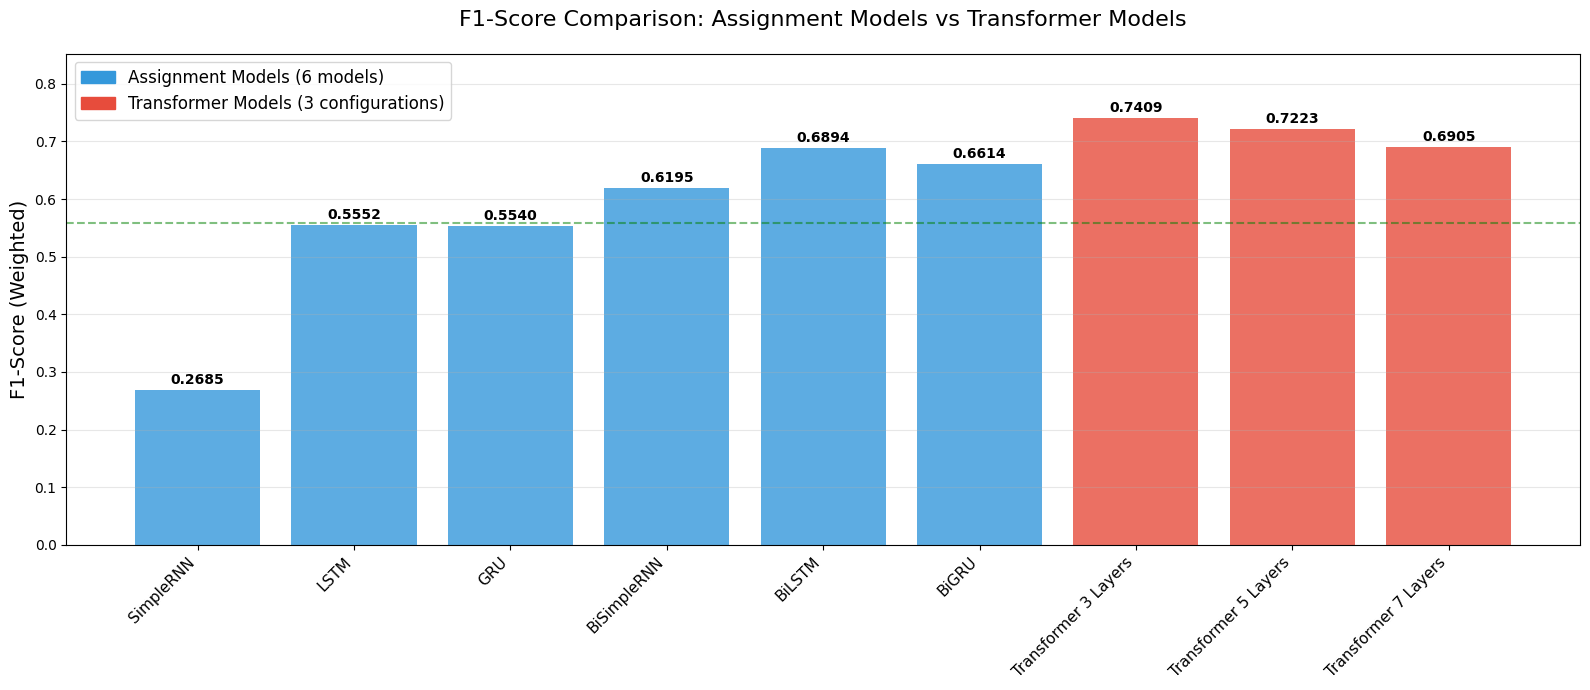

In [10]:
assignment_f1_scores = [0.2685, 0.5552, 0.5540, 0.6195, 0.6894, 0.6614]
assignment_model_names = ['SimpleRNN', 'LSTM', 'GRU', 'BiSimpleRNN', 'BiLSTM', 'BiGRU']

print("Assignment Models F1-Scores:")
for i, (name, score) in enumerate(zip(assignment_model_names, assignment_f1_scores)):
    print(f"  {name}: {score:.4f}")

#Transformer model F1-scores
transformer_f1_scores = [f1_scores[L] for L in layer_settings]

#Create labels for all models
all_labels = assignment_model_names + [f"Transformer {L} Layers" for L in layer_settings]
all_scores = assignment_f1_scores + transformer_f1_scores

#Create color scheme
colors = ['#3498db'] * len(assignment_f1_scores) + ['#e74c3c'] * len(transformer_f1_scores)

#Plot bar chart
plt.figure(figsize=(16, 7))
bars = plt.bar(range(len(all_labels)), all_scores, color=colors, alpha=0.8)

#Add value labels on top of bars
for bar, score in zip(bars, all_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{score:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

#Customize plot
plt.title("F1-Score Comparison: Assignment Models vs Transformer Models", fontsize=16, pad=20)
plt.ylabel("F1-Score (Weighted)", fontsize=14)
plt.ylim(0, max(all_scores) * 1.15)
plt.xticks(range(len(all_labels)), all_labels, rotation=45, ha='right', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

#Add horizontal line for average assignment score
avg_assignment_f1 = np.mean(assignment_f1_scores)
plt.axhline(y=avg_assignment_f1, color='green', linestyle='--', alpha=0.5,
           label=f'Assignment Avg: {avg_assignment_f1:.4f}')

#Add legend
import matplotlib.patches as mpatches
assignment_patch = mpatches.Patch(color='#3498db', label=f'Assignment Models ({len(assignment_f1_scores)} models)')
transformer_patch = mpatches.Patch(color='#e74c3c', label=f'Transformer Models ({len(transformer_f1_scores)} configurations)')
plt.legend(handles=[assignment_patch, transformer_patch], loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('f1_score_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()
